In [32]:
import pandas as pd
df = pd.read_csv("test4G.csv")

In [33]:
df1=df
df1["Day"] = (
    (df1["TimeBlock"].eq(1) & df1["TimeBlock"].shift().ne(1))
    .cumsum()
    + 1
)

In [34]:
result2 = (
    df1
    .groupby(["Day", "TimeBlock"])["DeviceScreenState"]
    .apply(lambda x: (x == 1).sum())  # đếm số dòng =1
    .reset_index(name="Count")
)

In [39]:
result3 = result2.iloc[50:150]

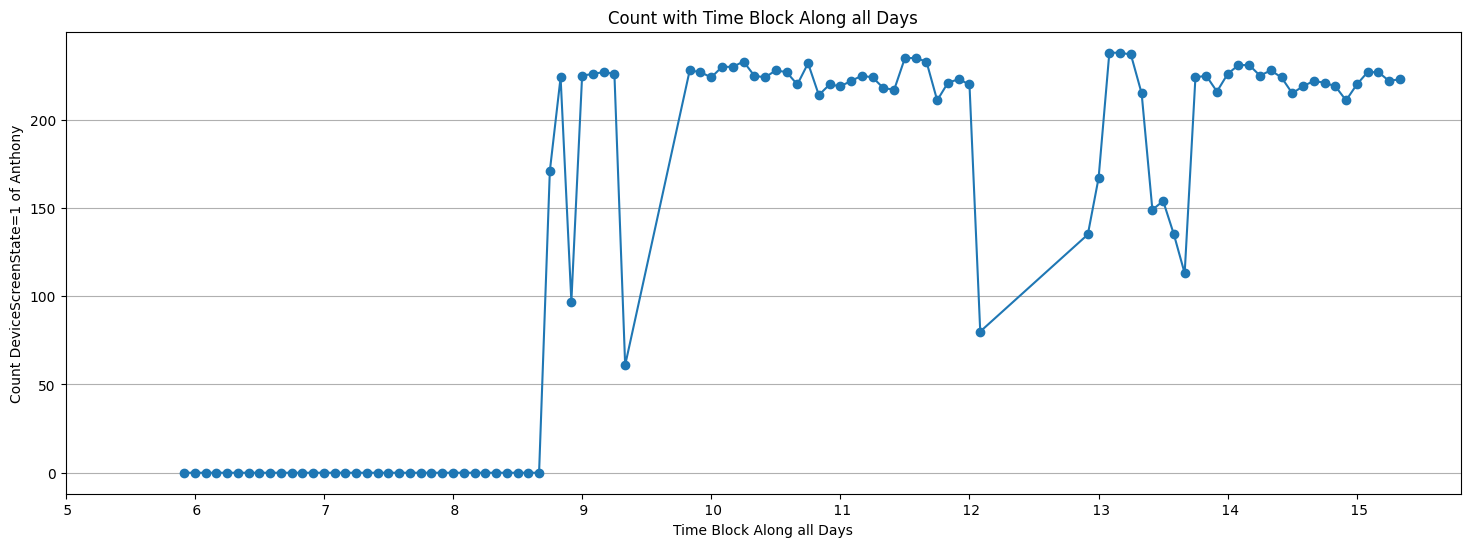

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Sắp xếp theo Day và TimeBlock
result = result3.sort_values(["Day", "TimeBlock"]).reset_index(drop=True)

# Tạo trục x liên tục
result["x_pos"] = (result["Day"] - 1) * 12 + result["TimeBlock"]

plt.figure(figsize=(18,6))
plt.plot(result["x_pos"], result["Count"], marker="o")

plt.xlabel("Time Block Along all Days")
plt.ylabel("Count DeviceScreenState=1 of Anthony")
plt.title("Count with Time Block Along all Days")

# ===== CHỈ HIỂN THỊ NGÀY TRÊN TRỤC X (ĐẦU MỖI NGÀY) =====
days = result["Day"].unique()

# vị trí tick = TimeBlock đầu tiên của mỗi ngày
x_ticks = (days - 1) * 12 + 1

plt.xticks(x_ticks, [f" {d}" for d in days])

# chỉ grid ngang
plt.grid(axis="y")

plt.show()


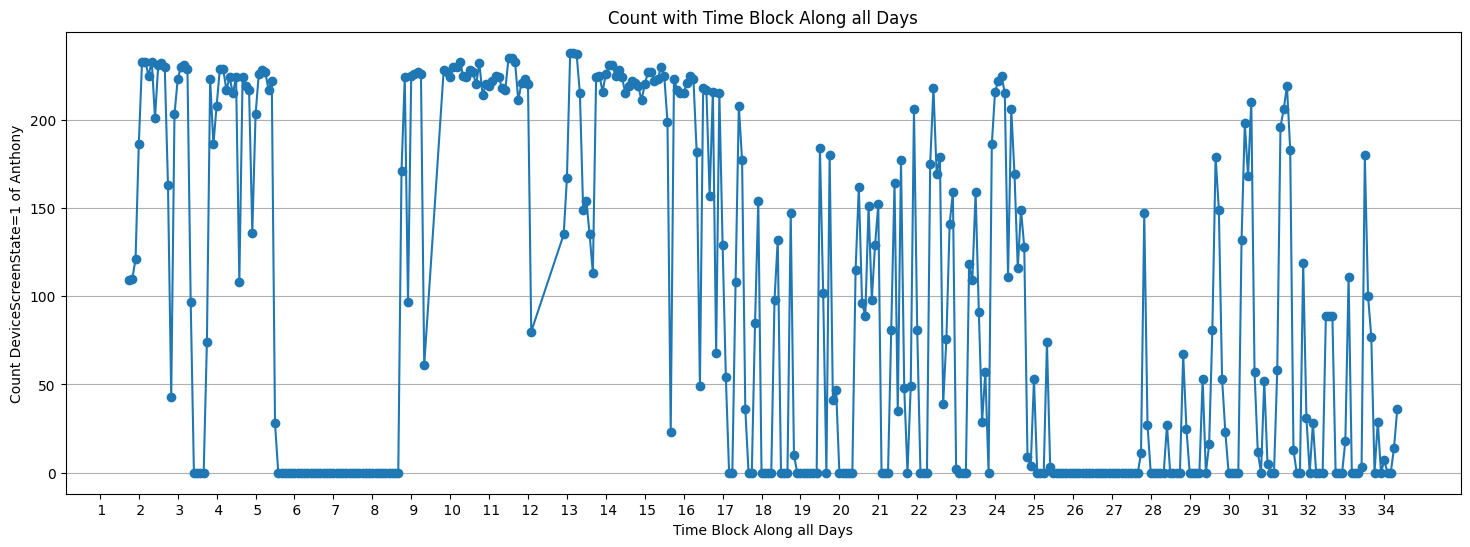

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Sắp xếp theo Day và TimeBlock
result = result2.sort_values(["Day", "TimeBlock"]).reset_index(drop=True)

# Tạo trục x liên tục
result["x_pos"] = (result["Day"] - 1) * 12 + result["TimeBlock"]

plt.figure(figsize=(18,6))
plt.plot(result["x_pos"], result["Count"], marker="o")

plt.xlabel("Time Block Along all Days")
plt.ylabel("Count DeviceScreenState=1 of Anthony")
plt.title("Count with Time Block Along all Days")

# ===== CHỈ HIỂN THỊ NGÀY TRÊN TRỤC X (ĐẦU MỖI NGÀY) =====
days = result["Day"].unique()

# vị trí tick = TimeBlock đầu tiên của mỗi ngày
x_ticks = (days - 1) * 12 + 1

plt.xticks(x_ticks, [f" {d}" for d in days])

# chỉ grid ngang
plt.grid(axis="y")

plt.show()


In [26]:
result3 = result2.iloc[0:182]

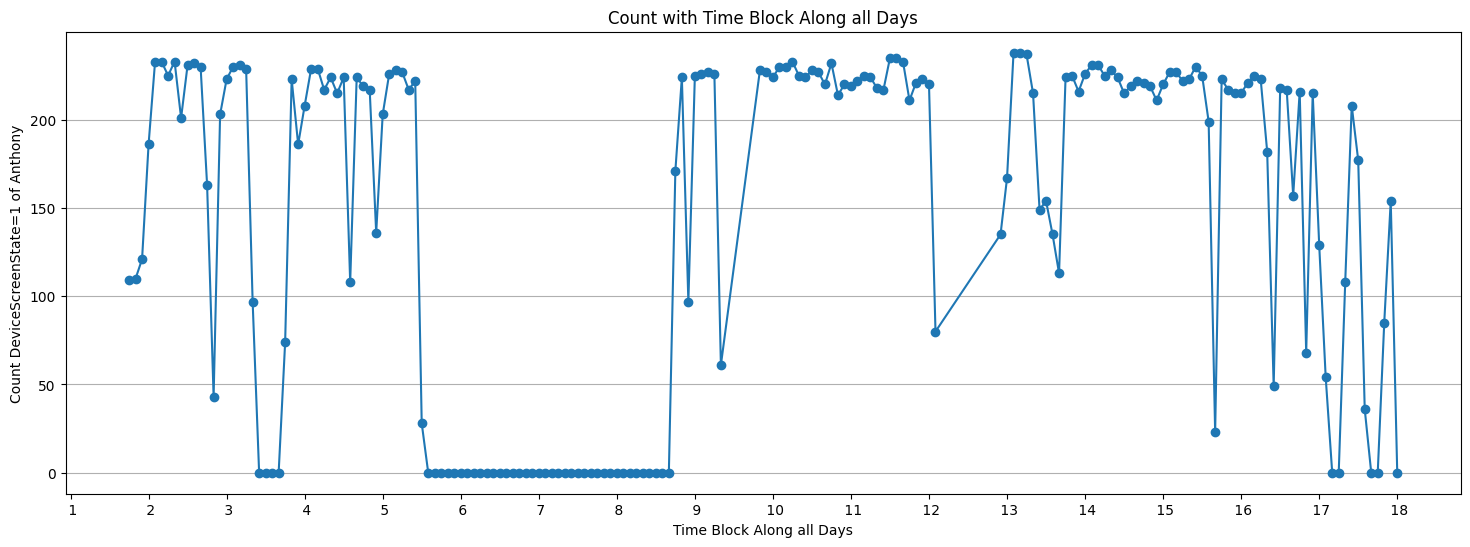

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Sắp xếp theo Day và TimeBlock
result = result3.sort_values(["Day", "TimeBlock"]).reset_index(drop=True)

# Tạo trục x liên tục
result["x_pos"] = (result["Day"] - 1) * 12 + result["TimeBlock"]

plt.figure(figsize=(18,6))
plt.plot(result["x_pos"], result["Count"], marker="o")

plt.xlabel("Time Block Along all Days")
plt.ylabel("Count DeviceScreenState=1 of Anthony")
plt.title("Count with Time Block Along all Days")

# ===== CHỈ HIỂN THỊ NGÀY TRÊN TRỤC X (ĐẦU MỖI NGÀY) =====
days = result["Day"].unique()

# vị trí tick = TimeBlock đầu tiên của mỗi ngày
x_ticks = (days - 1) * 12 + 1

plt.xticks(x_ticks, [f" {d}" for d in days])

# chỉ grid ngang
plt.grid(axis="y")

plt.show()


In [28]:
result3 = result2.iloc[181:1000]

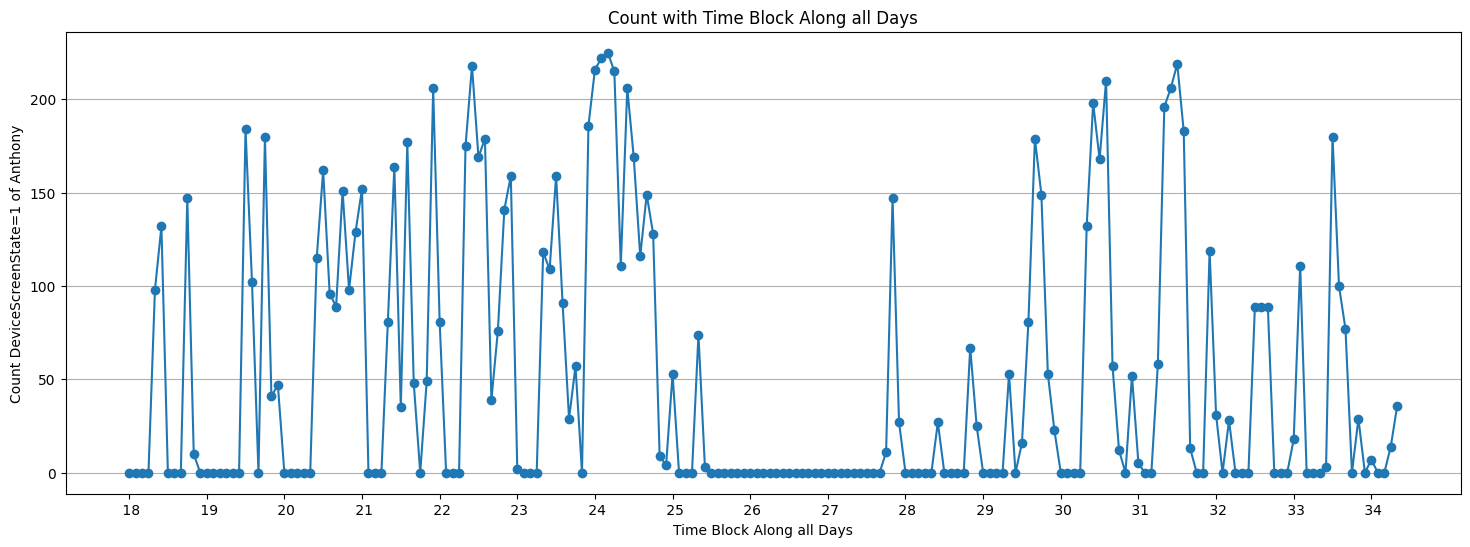

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Sắp xếp theo Day và TimeBlock
result = result3.sort_values(["Day", "TimeBlock"]).reset_index(drop=True)

# Tạo trục x liên tục
result["x_pos"] = (result["Day"] - 1) * 12 + result["TimeBlock"]

plt.figure(figsize=(18,6))
plt.plot(result["x_pos"], result["Count"], marker="o")

plt.xlabel("Time Block Along all Days")
plt.ylabel("Count DeviceScreenState=1 of Anthony")
plt.title("Count with Time Block Along all Days")

# ===== CHỈ HIỂN THỊ NGÀY TRÊN TRỤC X (ĐẦU MỖI NGÀY) =====
days = result["Day"].unique()

# vị trí tick = TimeBlock đầu tiên của mỗi ngày
x_ticks = (days - 1) * 12 + 1

plt.xticks(x_ticks, [f" {d}" for d in days])

# chỉ grid ngang
plt.grid(axis="y")

plt.show()


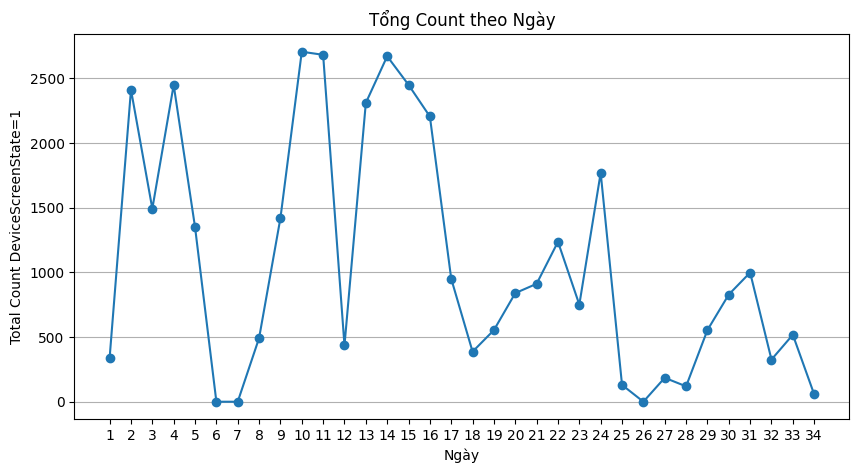

In [66]:
import matplotlib.pyplot as plt

# Count theo ngày (tổng Count mỗi ngày)
daily_count = (
    result2
    .groupby("Day")["Count"]
    .sum()
    .reset_index()
)

# Vẽ biểu đồ
plt.figure(figsize=(10,5))
plt.plot(daily_count["Day"], daily_count["Count"], marker="o")

plt.xlabel("Ngày")
plt.ylabel("Total Count DeviceScreenState=1")
plt.title("Tổng Count theo Ngày")

plt.grid(axis="y")
plt.xticks(daily_count["Day"])  # hiển thị từng ngày
plt.show()


In [20]:
df_new1 = (
    result2
    .groupby("TimeBlock", as_index=False)["Count"]
    .sum()
)

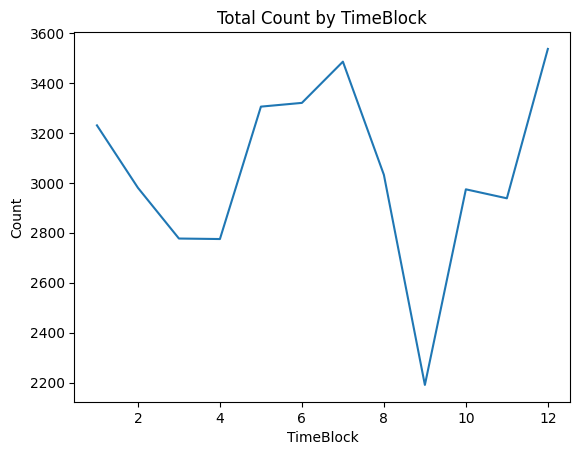

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_new1["TimeBlock"], df_new1["Count"])
plt.xlabel("TimeBlock")
plt.ylabel("Count")
plt.title("Total Count by TimeBlock")
plt.show()

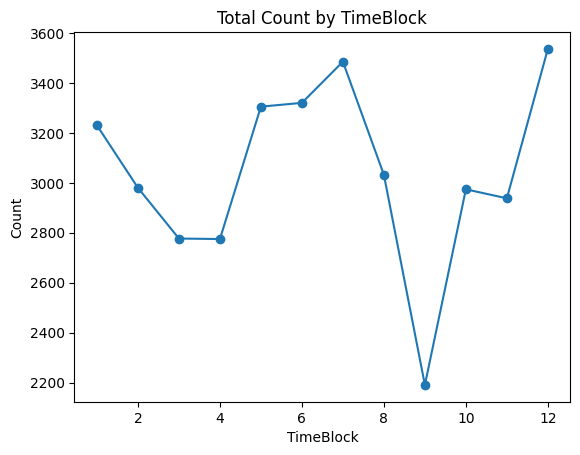

In [70]:
import matplotlib.pyplot as plt

# Sắp xếp TimeBlock trước khi vẽ (rất quan trọng)
df_new2 = df_new1.sort_values("TimeBlock")

plt.figure()
plt.plot(df_new2["TimeBlock"], df_new2["Count"],marker="o")
#plt.bar(df_new2["TimeBlock"], df_new2["Count"])
#plt.plot(daily_count["Day"], daily_count["Count"], marker="o")
plt.xlabel("TimeBlock")
plt.ylabel("Count")
plt.title("Total Count by TimeBlock")
plt.show()

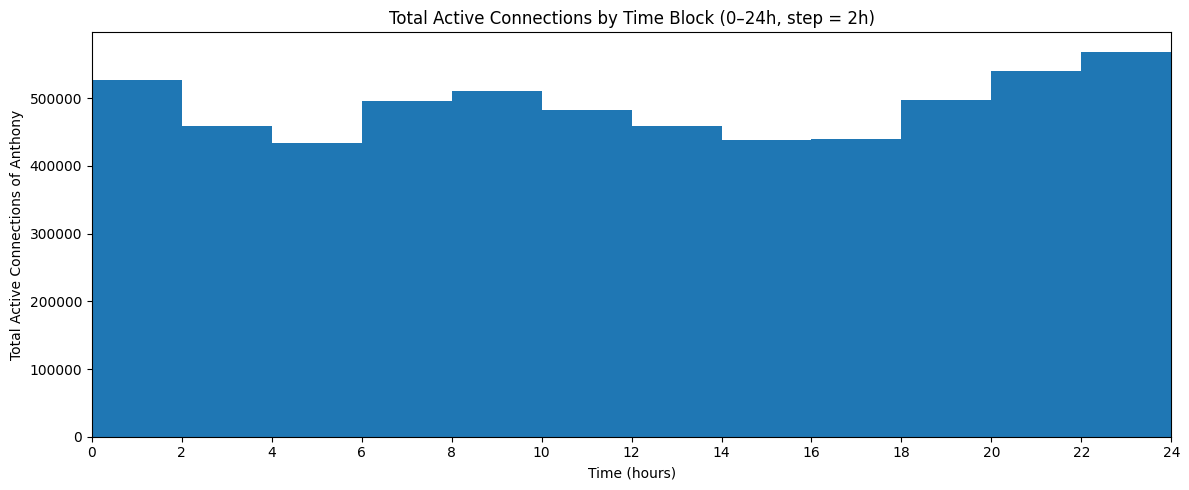

In [30]:
# ===== 1. Data normalization =====
df["ActiveConnections"] = df["ActiveConnections"].astype(int)
df["TimeBlock"] = df["TimeBlock"].astype(int)

block_size = 2
TOTAL_HOURS = 24
NUM_BLOCKS = TOTAL_HOURS // block_size  # 12

# ===== 2. Total ActiveConnections per TimeBlock (1 → 12) =====
result = (
    df
    .groupby("TimeBlock")["ActiveConnections"]
    .sum()
    .reindex(range(1, NUM_BLOCKS + 1), fill_value=0)
    .reset_index(name="total_active_connections")
)

# ===== 3. Time block → hour (left edge) =====
result["x_left"] = (result["TimeBlock"] - 1) * block_size

# ===== 4. Draw bar chart =====
plt.figure(figsize=(12, 5))

plt.bar(
    x=result["x_left"],
    height=result["total_active_connections"],
    width=block_size,
    align="edge"
)

# ===== 5. X-axis: 0–24, step = 2 =====
xticks = list(range(0, TOTAL_HOURS + 1, block_size))
plt.xticks(xticks)
plt.xlim(0, TOTAL_HOURS)

plt.xlabel("Time (hours)")
plt.ylabel("Total Active Connections of Anthony")
plt.title("Total Active Connections by Time Block (0–24h, step = 2h)")

plt.tight_layout()
plt.show()

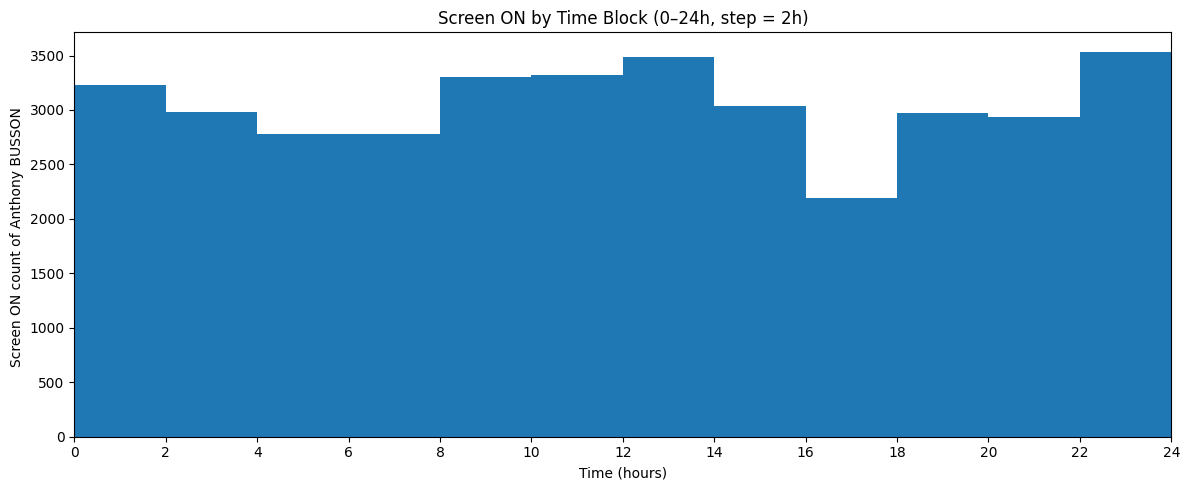

In [31]:

# ===== 1. Data normalization =====
df["DeviceScreenState"] = df["DeviceScreenState"].astype(int)
df["TimeBlock"] = df["TimeBlock"].astype(int)

block_size = 2
TOTAL_HOURS = 24
NUM_BLOCKS = TOTAL_HOURS // block_size  # 12

# ===== 2. Create complete Time Blocks 1 → 12 =====
result = (
    df[df["DeviceScreenState"] == 1]
    .groupby("TimeBlock")
    .size()
    .reindex(range(1, NUM_BLOCKS + 1), fill_value=0)
    .reset_index(name="total_rows")
)

# ===== 3. Time Block → hour (left edge) =====
result["x_left"] = (result["TimeBlock"] - 1) * block_size

# ===== 4. Draw bar chart =====
plt.figure(figsize=(12, 5))

plt.bar(
    x=result["x_left"],
    height=result["total_rows"],
    width=block_size,
    align="edge"
)

# ===== 5. X-axis: 0–24, step = 2 (DO NOT label 0–2) =====
xticks = list(range(0, TOTAL_HOURS + 1, block_size))
plt.xticks(xticks)
plt.xlim(0, TOTAL_HOURS)

plt.xlabel("Time (hours)")
plt.ylabel("Screen ON count of Anthony BUSSON ")
plt.title("Screen ON by Time Block (0–24h, step = 2h)")

plt.tight_layout()
plt.show()